In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

%matplotlib inline
#from brokenaxes import brokenaxes


plt.rc('lines', linewidth=4)
plt.rc('legend',fontsize=16)
plt.rc('axes',labelsize=16)
plt.rc('xtick',labelsize=12)
plt.rc('xtick',direction='in')
plt.rc('ytick',labelsize=12)
plt.rc('axes',labelsize=16)
plt.rc('ytick',direction='in')
plt.rc('figure',figsize=(8,6))


In [2]:
dat = pd.read_csv('objective/psf 400.txt',    names=('i','x','y')     )
dat852 = pd.read_csv('objective/psf 852.txt',    header =14 , delimiter = '\t')


In [5]:
plt.figure(figsize =(4,3), dpi=200)
pmag = 125.9988
pmag852 = 7.57

plt.plot([-5,5],[.8,.8], color = 'grey', linestyle = '--', linewidth =1)
plt.plot(dat852['Position']/pmag852, dat852['Value'], color = 'r')

plt.plot(dat['x']/pmag, dat['y'], color = 'b')

#plt.plot([-.25,.25], [.5,.5])
plt.xlim(-2.5,2.5)

plt.ylim(0,1)
plt.yticks([0,.8,1])
plt.xlabel(r'position ($\mu m$)')
plt.ylabel(r'relative irradiance')
plt.title('Point Spread Function')
plt.savefig('psf.pdf')

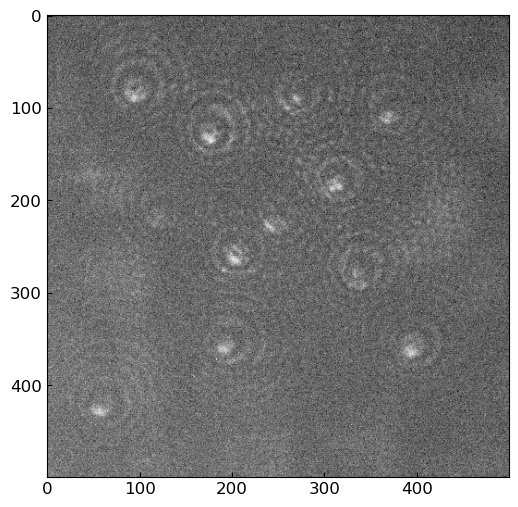

(0, 3)


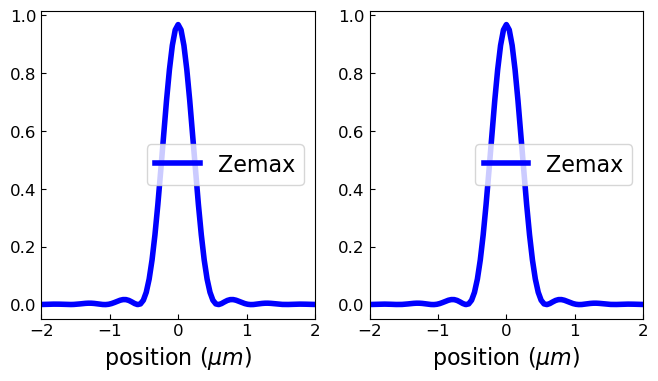

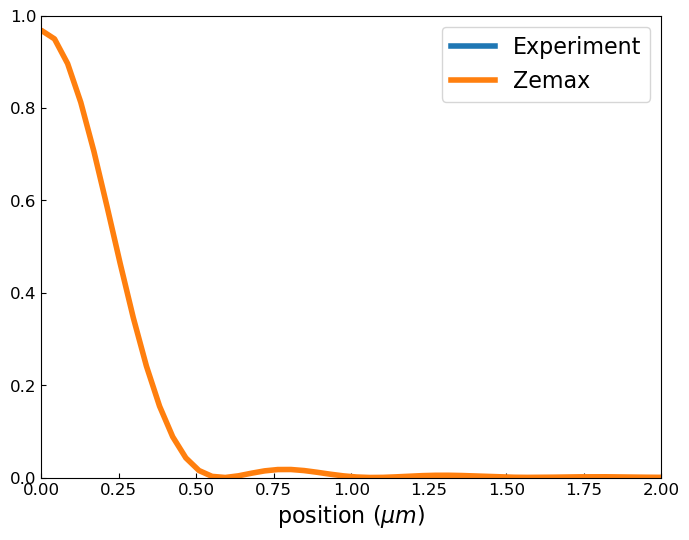

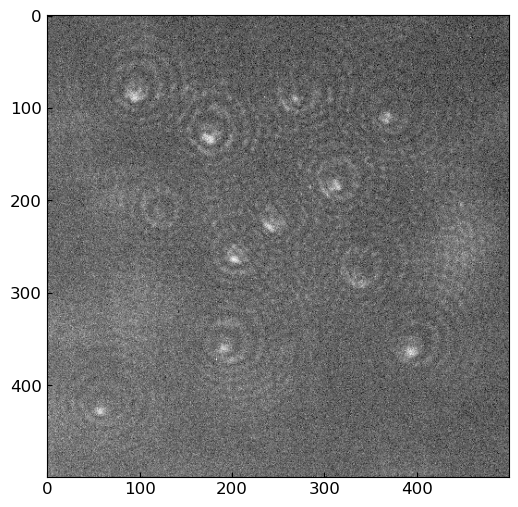

(0, 3)


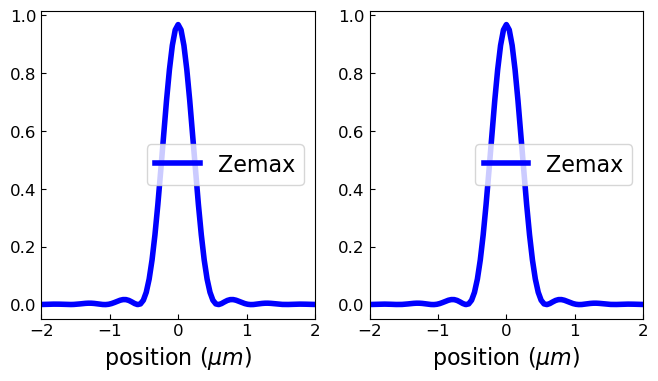

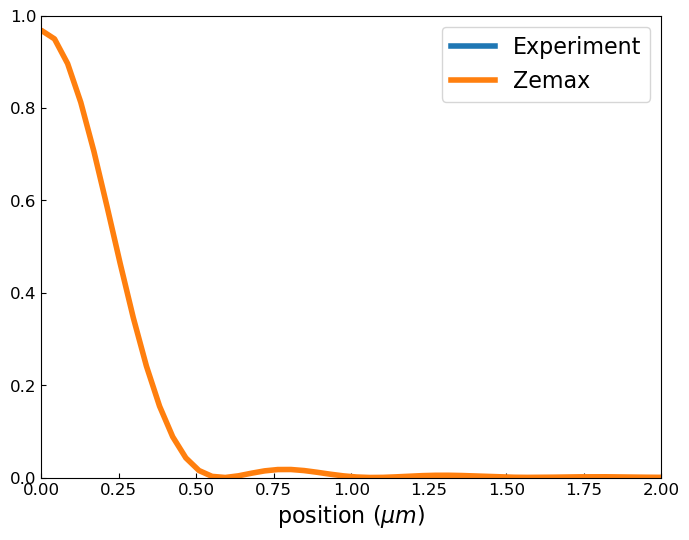

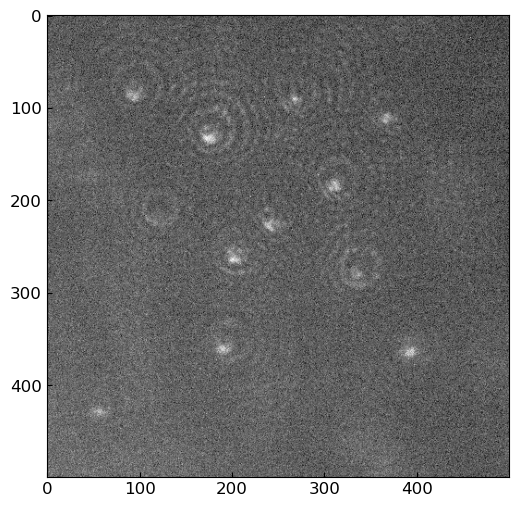

(0, 3)


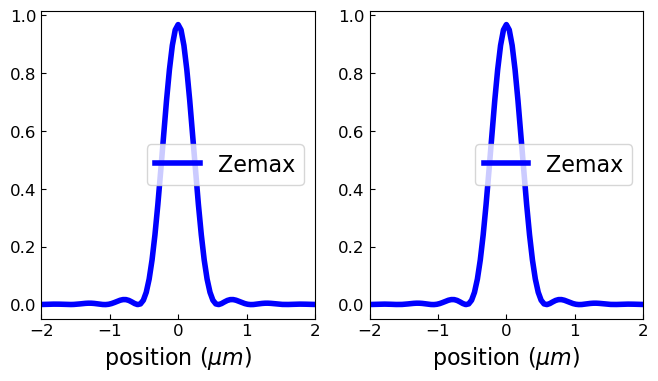

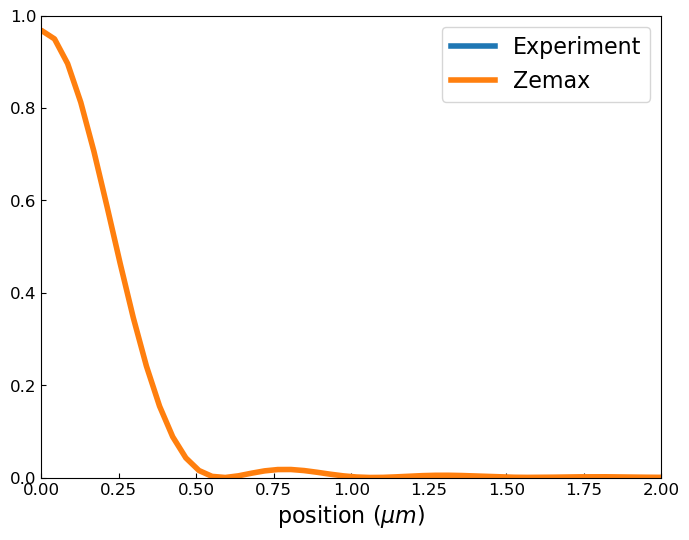

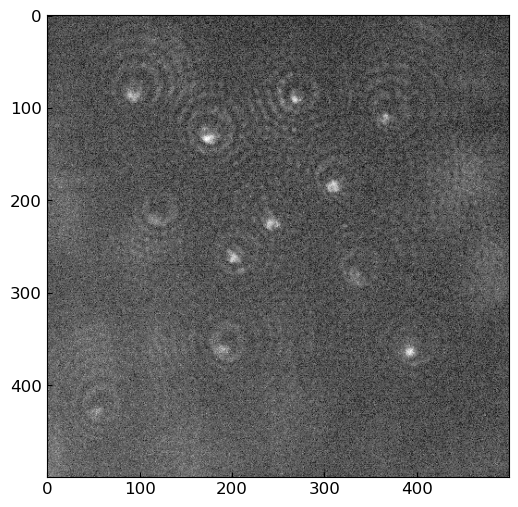

(0, 3)


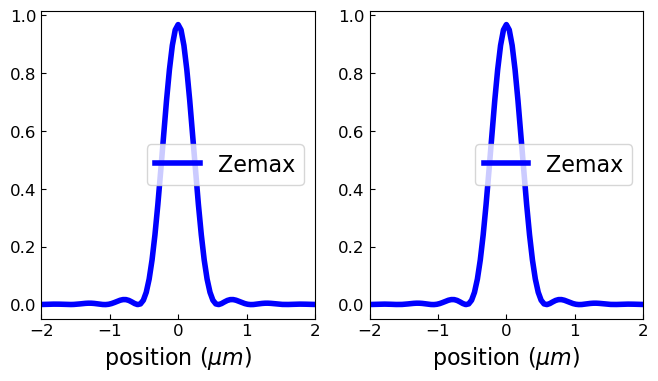

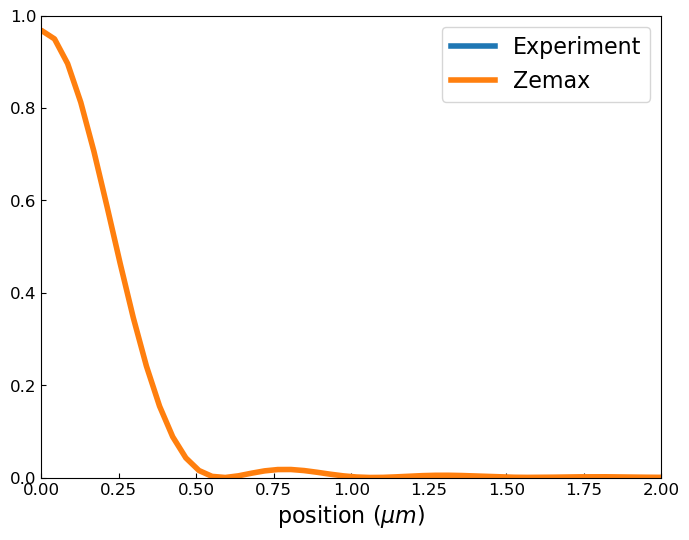

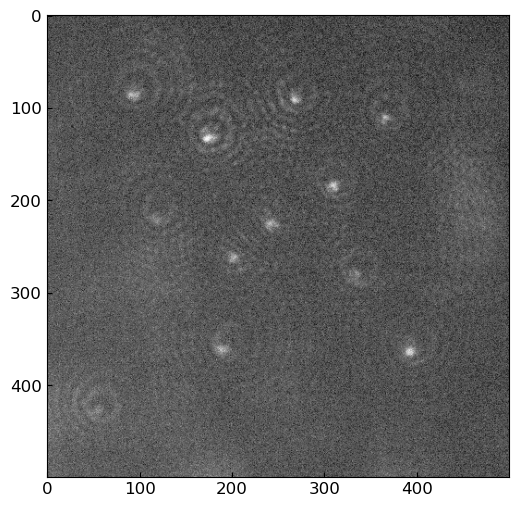

(0, 3)


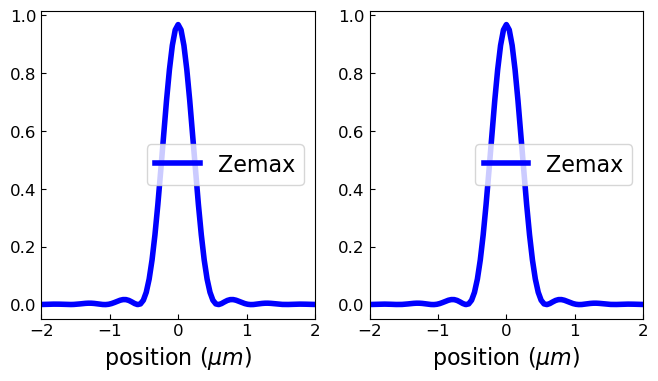

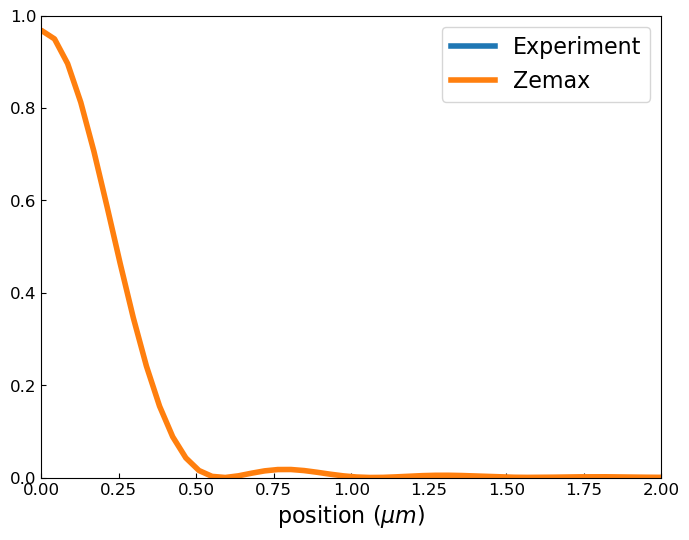

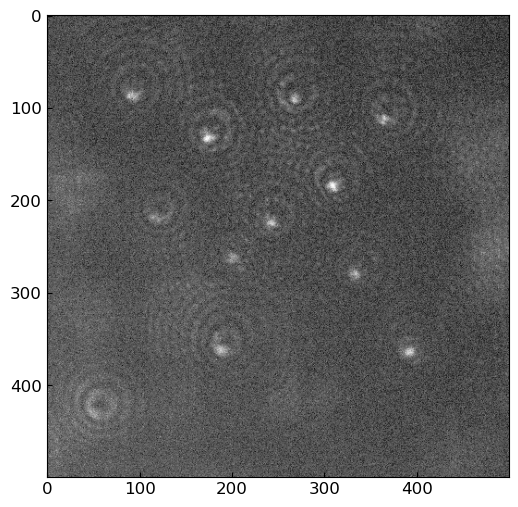

(0, 3)


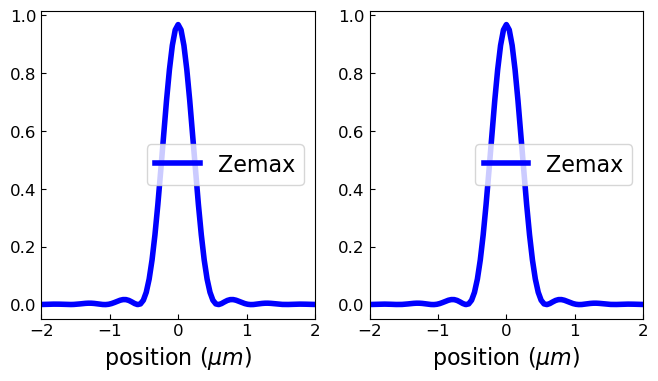

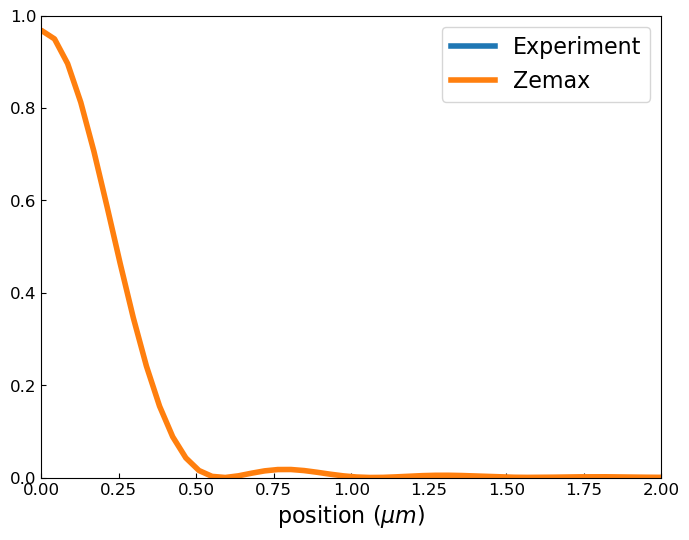

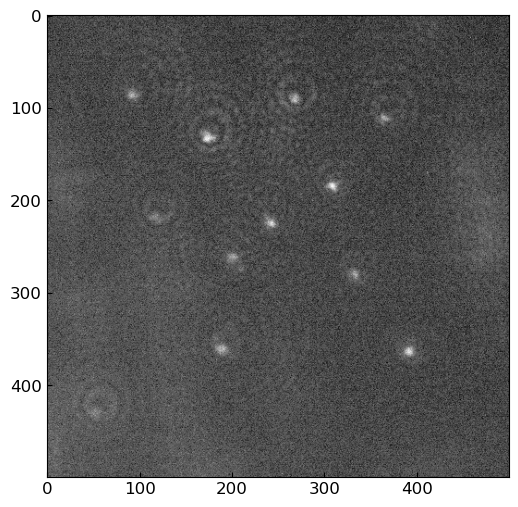

(0, 3)


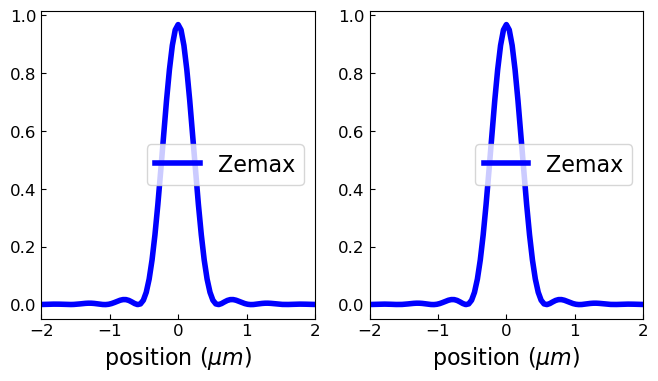

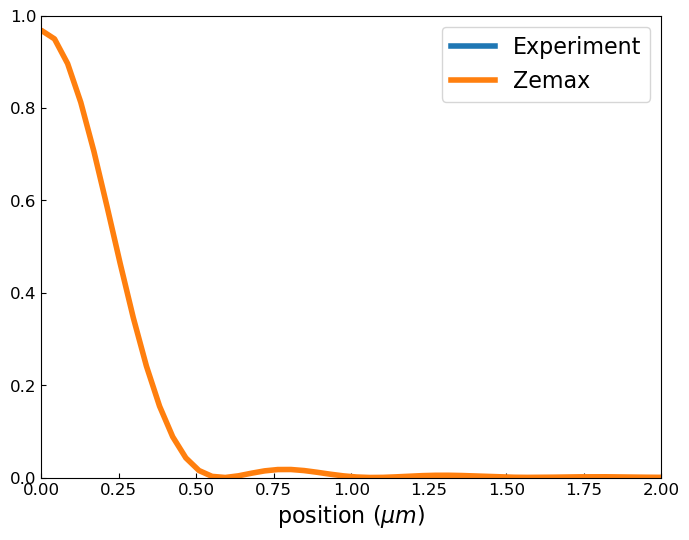

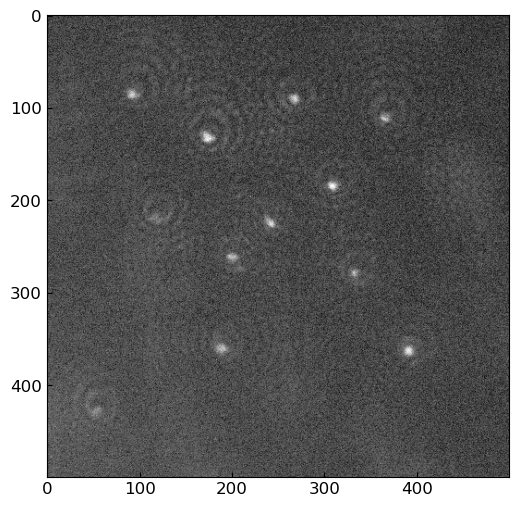

(0, 3)


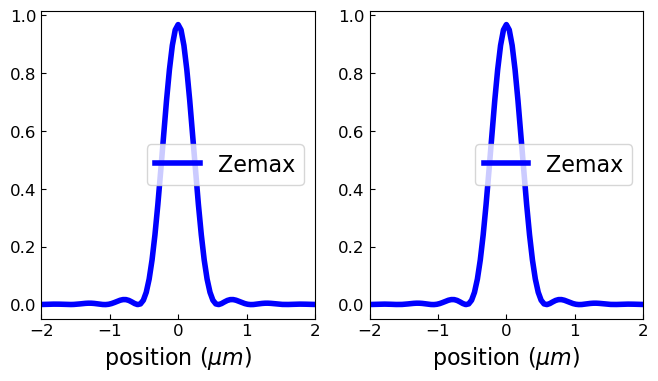

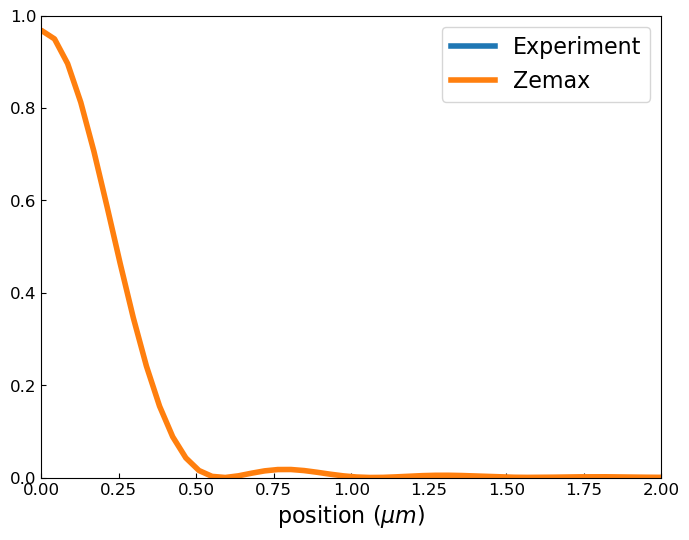

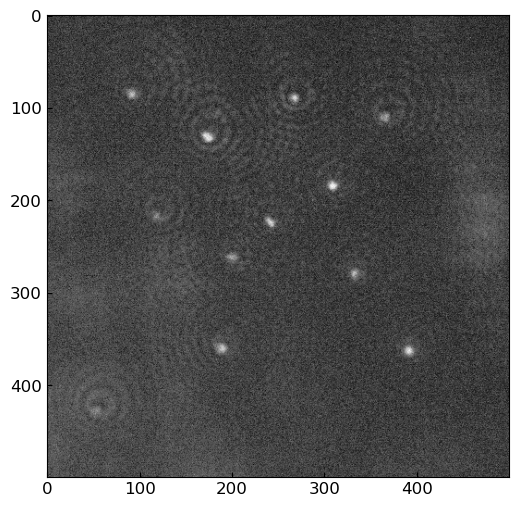

(0, 3)


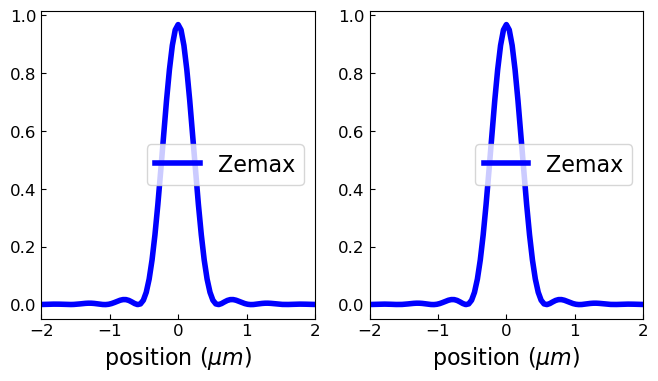

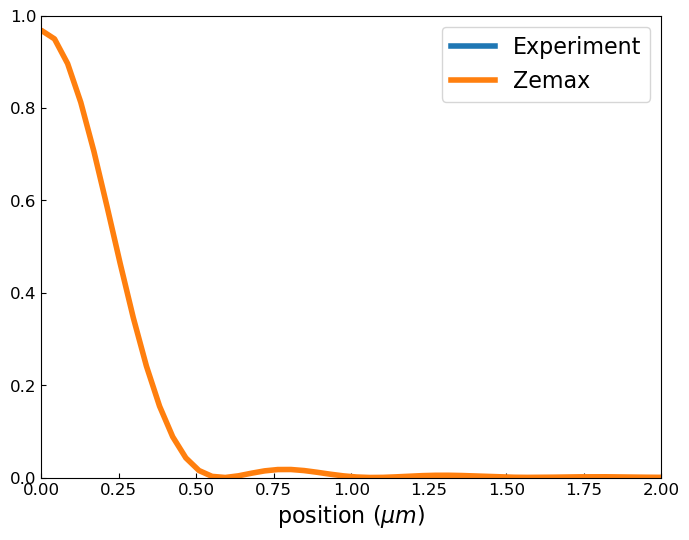

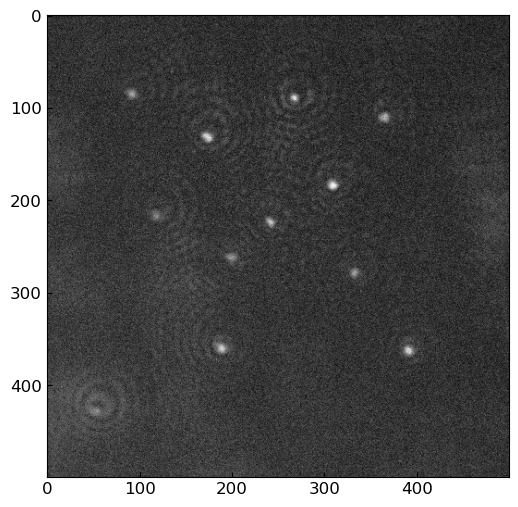

(0, 3)


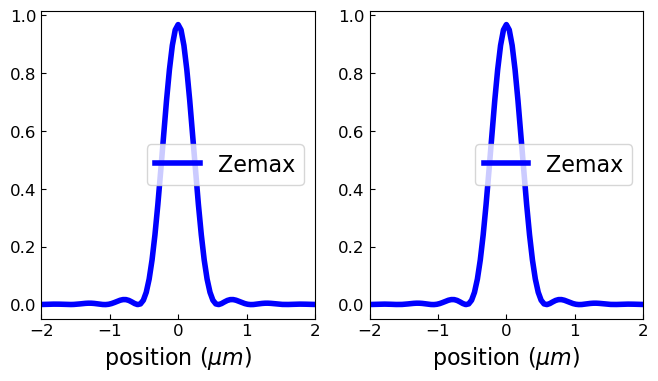

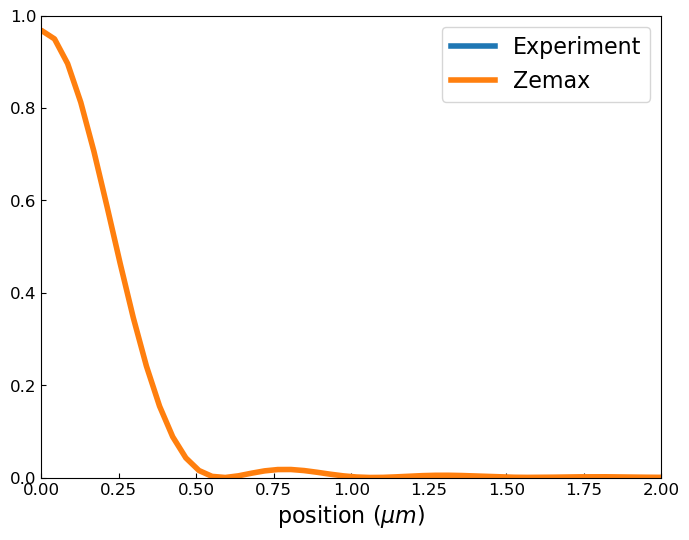

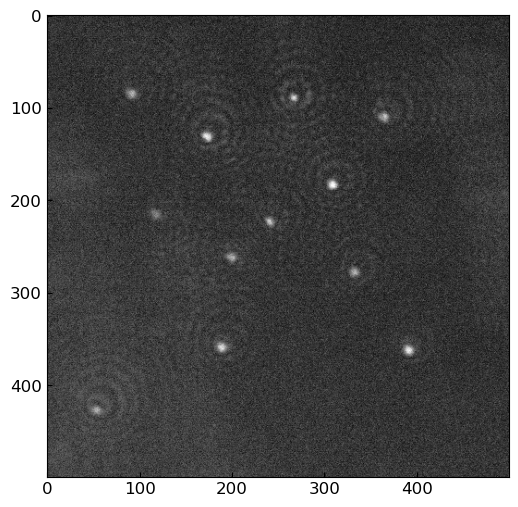

(0, 3)


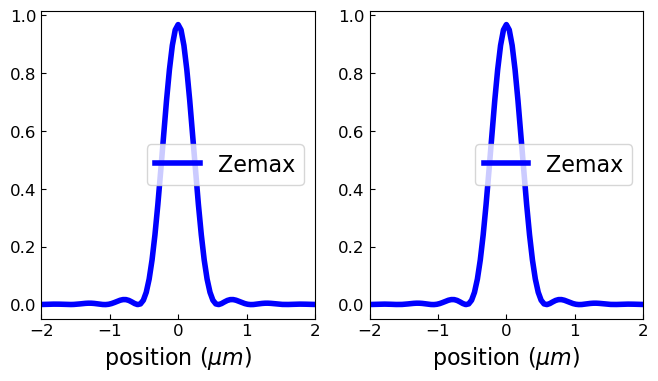

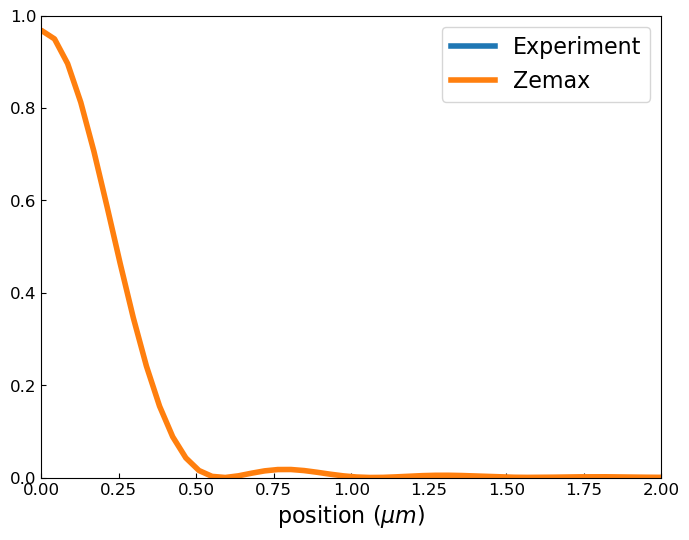

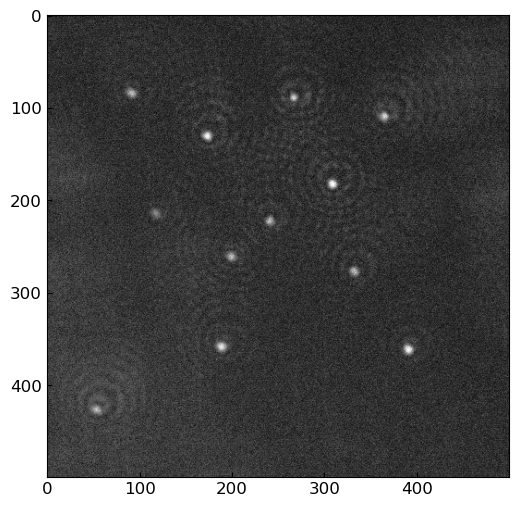

(0, 3)


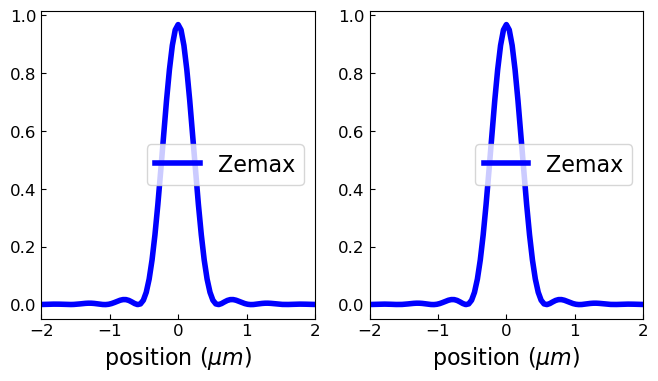

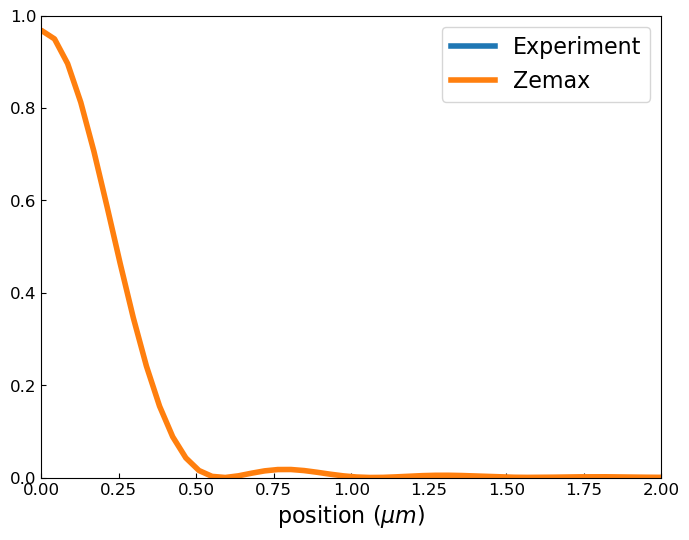

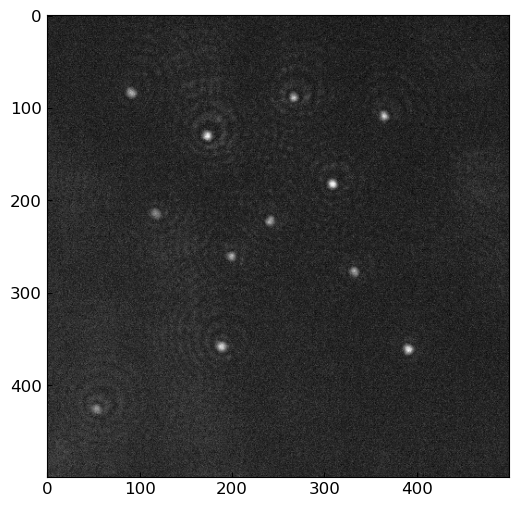

(0, 3)


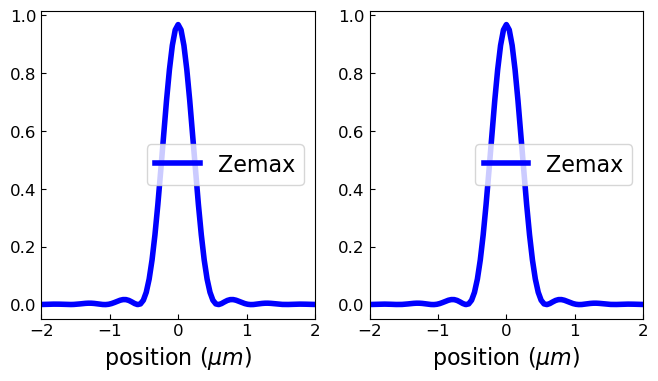

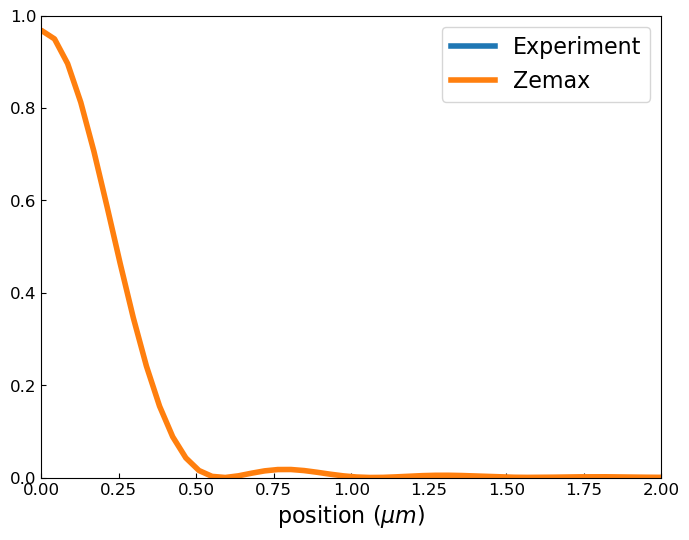

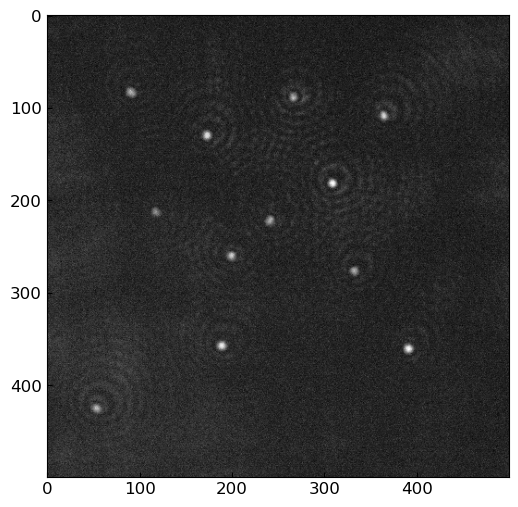

(0, 3)


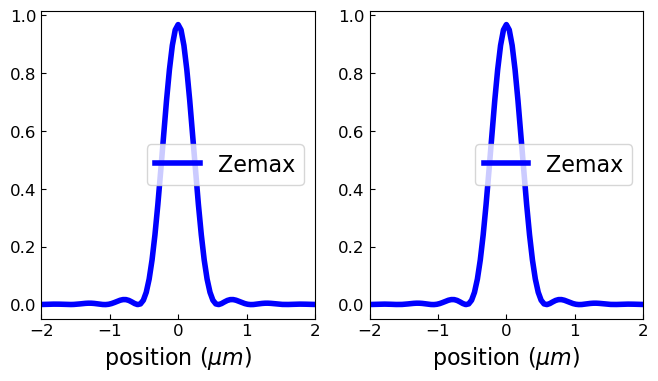

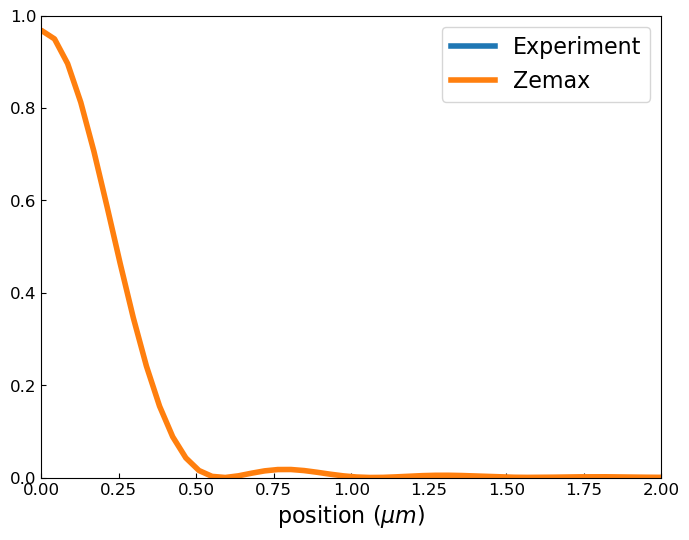

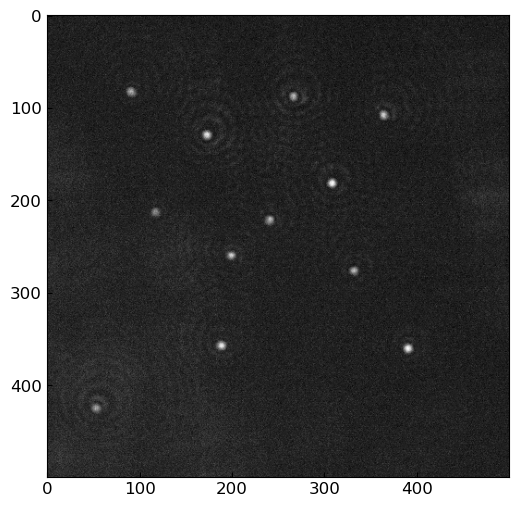

(1, 3)
(41, 41)
(41, 41)


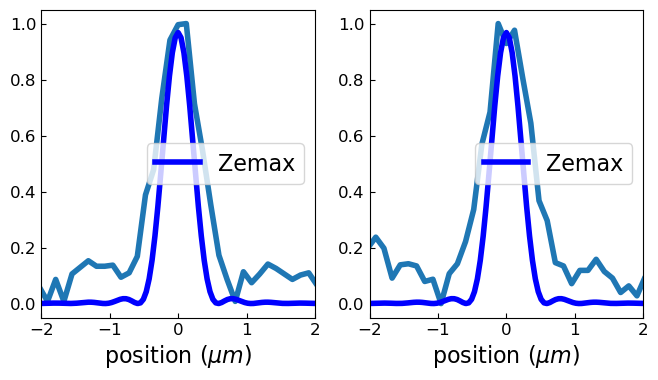

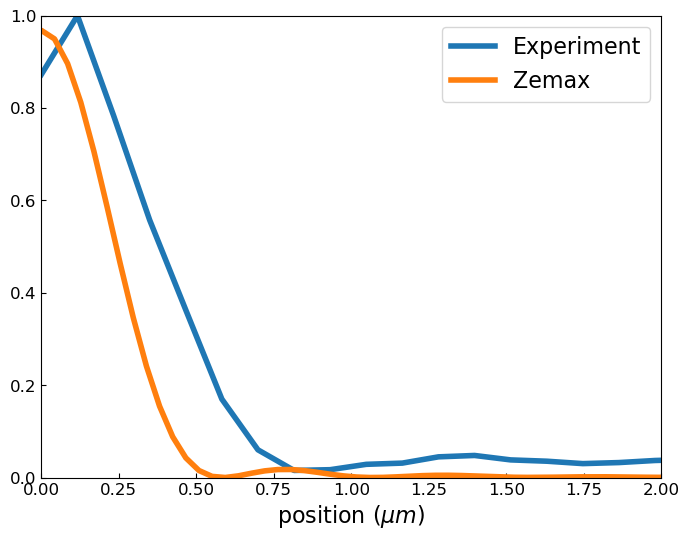

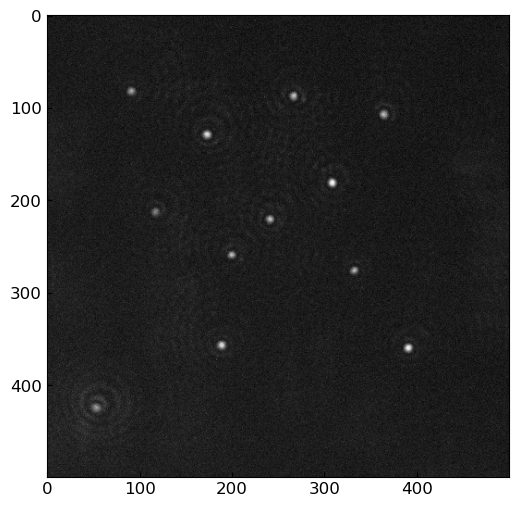

(2, 3)
(41, 41)
(41, 41)
(41, 41)
(41, 41)


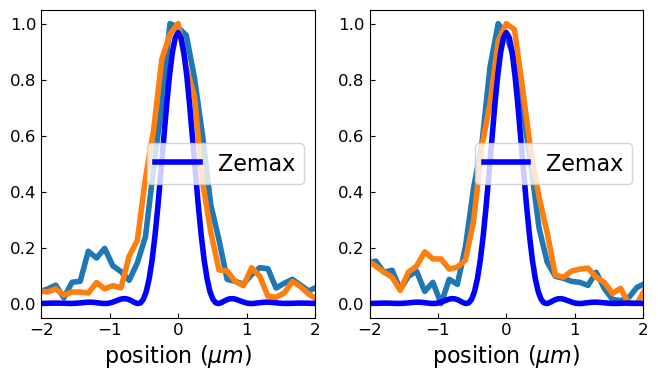

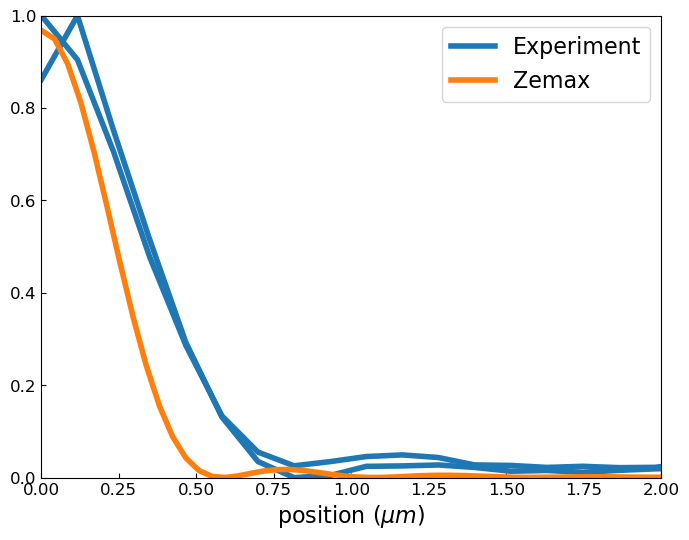

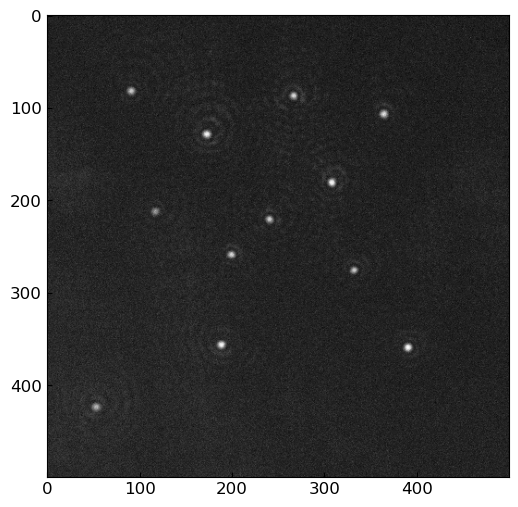

(4, 3)
(41, 41)
(41, 41)
(41, 41)
(41, 41)
(41, 41)
(41, 41)
(41, 41)
(41, 41)


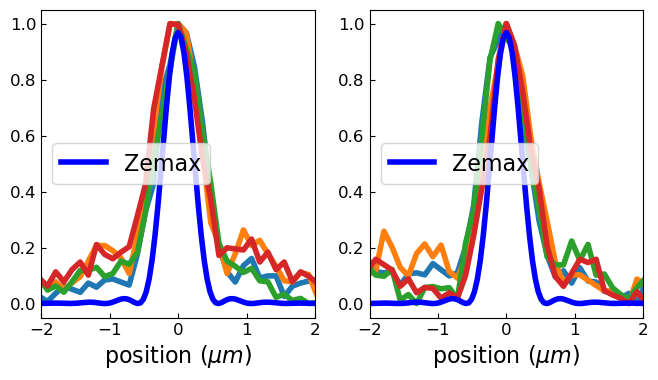

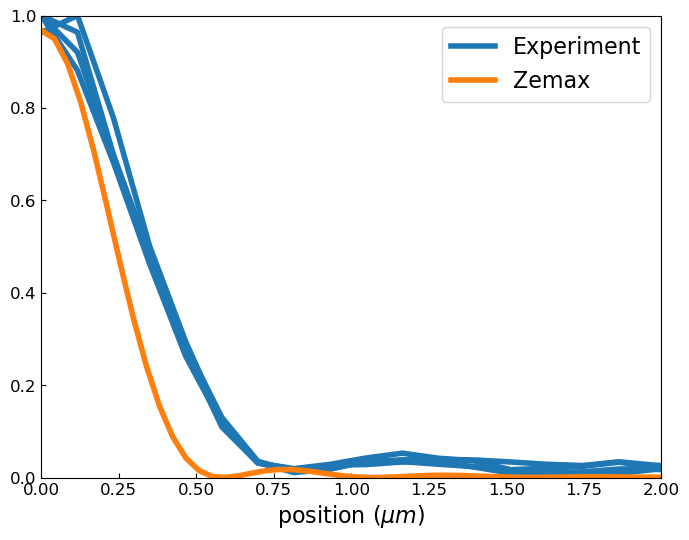

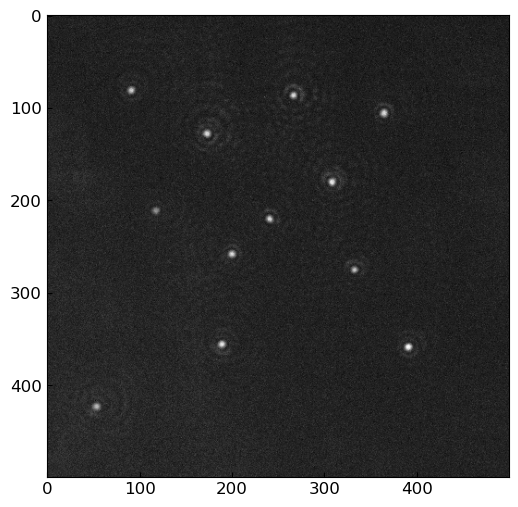

(3, 3)
(41, 41)
(41, 41)
(41, 41)
(41, 41)
(41, 41)
(41, 41)


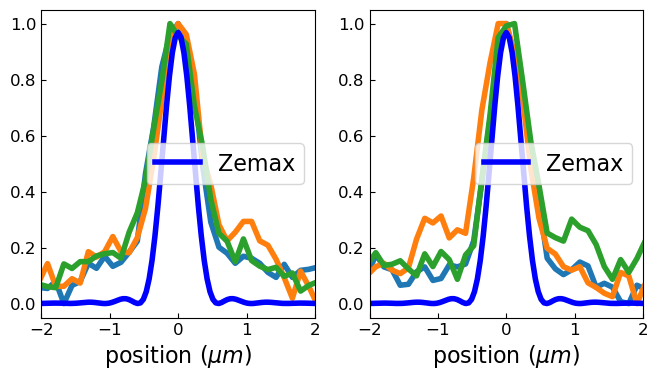

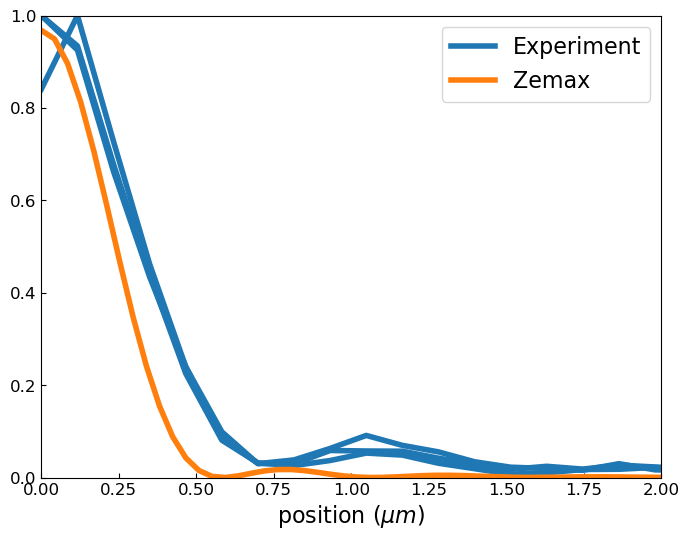

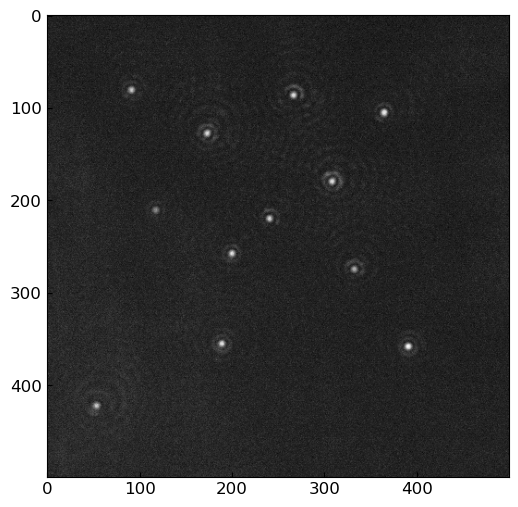

(2, 3)
(41, 41)
(41, 41)
(41, 41)
(41, 41)


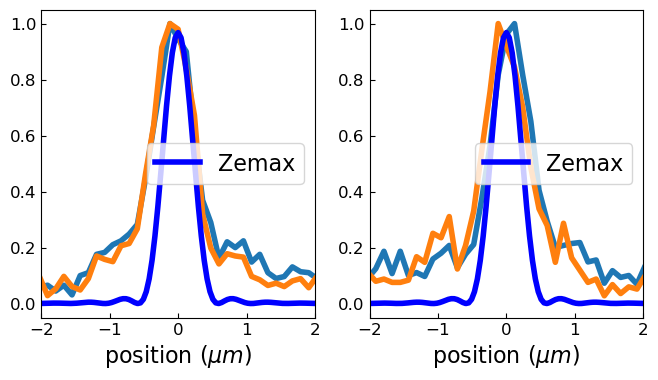

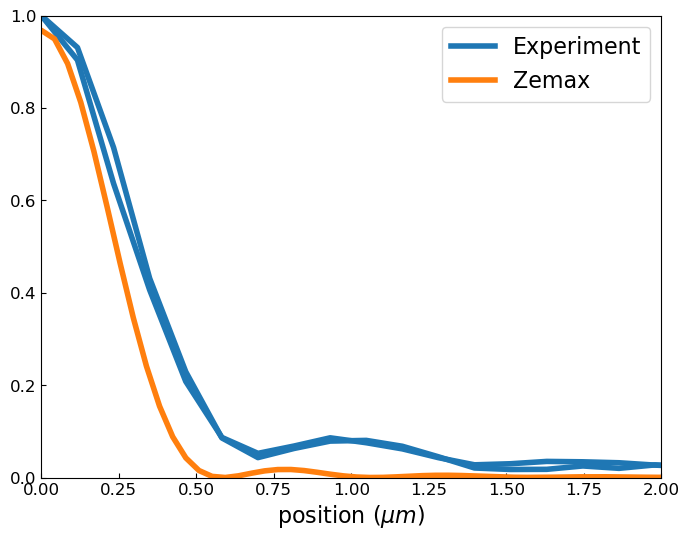

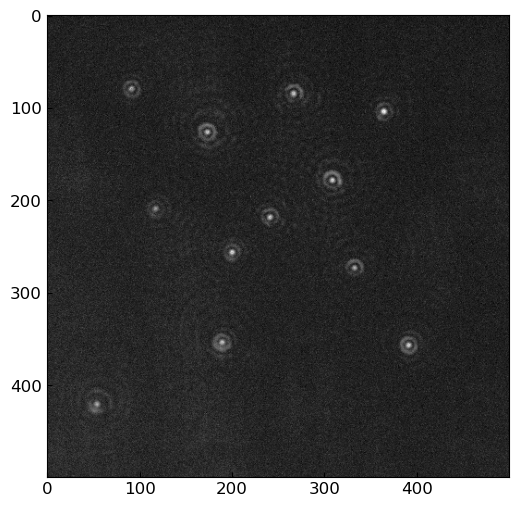

(0, 3)


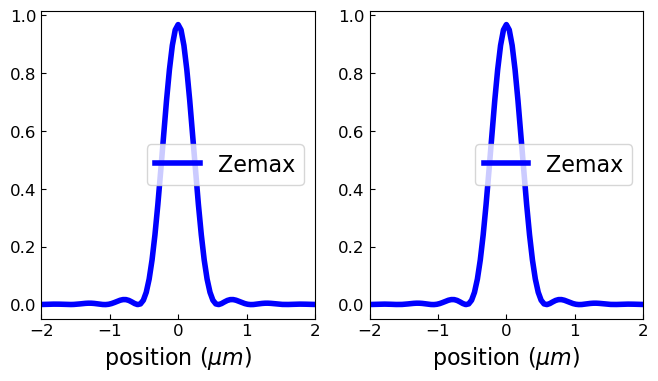

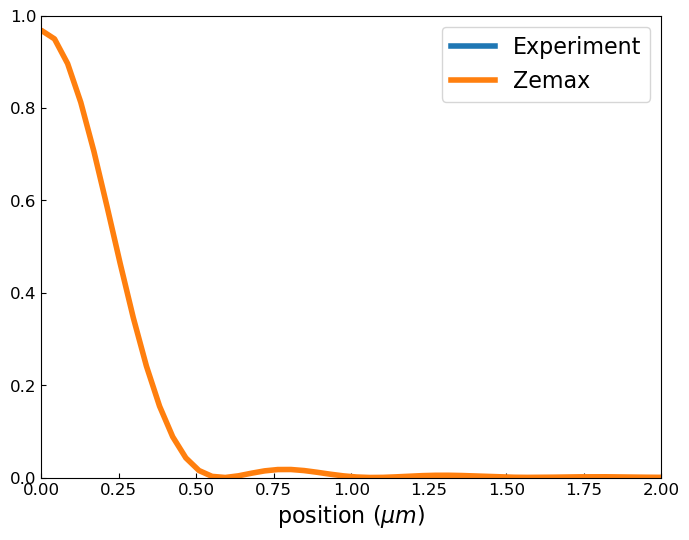

In [ ]:
from PIL import Image


def radial_profile(data, center):
    y, x = np.indices((data.shape))
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    r = r.astype(int)

    tbin = np.bincount(r.ravel(), data.ravel())
    nr = np.bincount(r.ravel())
    radialprofile = tbin / nr
    return np.unique(r),radialprofile 

import os


directory = os.fsencode("objective/images/zstack200nm2Vdown/")
stack = []
for i,file in enumerate(sorted(os.listdir(directory))[5:-5]):
    #plt.figure(dpi=200)
    filename = os.fsdecode(directory+file)
    im = np.array(Image.open(filename))
    im = im[700:1200,1600:2100] 
    plt.imshow(im, cmap= 'Greys_r')
    plt.show()




    from skimage.feature import blob_dog, blob_log, blob_doh

    blobs = blob_dog(im, max_sigma=10, threshold=0.05)

    print(blobs.shape)
    margin = 20

    plt.figure(figsize=(12,4))
    for a in [0,1]:
        plt.subplot(1,3,a+1)
        for b in blobs:
            
            bim = im[int(b[0]-20):int(b[0]+21),int(b[1])-20:int(b[1]+21)]
            X_ = np.linspace(0, bim.shape[0])
            print(bim.shape)
            X_ = np.linspace(0, bim.shape[0]/8.5875, bim.shape[0])
            X_ = X_ - np.mean(X_)
            Y_ = np.sum(bim, axis = a)
            Y_ = Y_ - np.min(Y_)
            Y_ = Y_ / np.max(Y_)
            plt.plot(X_,Y_)
        plt.plot(dat['x']/pmag, dat['y'], color = 'b', label = 'Zemax')
        plt.legend()
        plt.xlim(-2,2)
        plt.xlabel(r'position ($\mu m$)')
    plt.show()




    for b in blobs:
            
            bim = im[int(b[0]-20):int(b[0]+21),int(b[1])-20:int(b[1]+21)]
            X_ = np.linspace(0, bim.shape[0])
            X_,Y_ = radial_profile(bim, (20,20))
            Y_ = Y_ - np.min(Y_)
            Y_ = Y_ / np.max(Y_)
            plt.plot(X_/8.5875,Y_, color = 'C0')
    plt.plot([],[], color = 'C0', label = 'Experiment')
    plt.plot(dat['x']/pmag, dat['y'], color = 'C1', label = 'Zemax')
    plt.legend()
    plt.xlim(0,2)
    plt.ylim(0,1)
    plt.xlabel(r'position ($\mu m$)')
    plt.show()
